# Feature Engineering
**Предмет:** Софтверски алгоритми у системима аутоматског управљања  
**Студент:** Марко Дурић РА 106-2023  
**Тема:** Вишекласна класификација метал поджанрова на основу аудио карактеристика

---

## Корак 1 – Увоз библиотека и учитавање података

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/cleaned_data.csv")

print("Shape:", df.shape)
print("Жанрови:", df["genre"].unique())
df.head()

Shape: (950, 20)
Жанрови: <StringArray>
['black-metal', 'thrash-metal', 'symphonic-metal', 'death-metal']
Length: 4, dtype: str


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre
0,2biGEMYnKkiqJXkS8Koiaw,Panopticon,Kentucky,Kentucky,18,201066,False,0.456,0.399,7,-16.311,1,0.0311,0.644000,0.656000,0.2310,0.6890,99.951,4,black-metal
1,0WTc2jsUgF4Y2MOz0aYvsR,Megadeth,Hidden Treasures,Paranoid,65,152600,True,0.355,0.973,4,-7.004,0,0.0710,0.000359,0.154000,0.1420,0.6280,187.385,4,thrash-metal
2,7aMY3p166A7gDvbugcE2Ao,Xandria,Ravenheart,Eversleeping,39,220040,False,0.501,0.339,7,-9.220,0,0.0300,0.905000,0.000105,0.1040,0.1330,130.026,4,symphonic-metal
3,3oxjWhYHcHE3xtrpQulOmd,Exodus,Pleasures of the Flesh,Seeds of Hate,22,297306,False,0.209,0.947,11,-5.313,1,0.1090,0.000002,0.197000,0.2470,0.2300,89.540,4,thrash-metal
4,3U9gogDStAfWxSm91PJuxb,Slayer,South Of Heaven,South Of Heaven,64,298533,True,0.310,0.991,5,-3.769,0,0.3160,0.000132,0.085000,0.0969,0.0395,140.071,4,thrash-metal


## Корак 2 – Уклањање нерелевантних колона

In [2]:
#
drop_cols = ["track_id", "artists", "album_name", "track_name"]

df = df.drop(columns=drop_cols)

print("Преостале колоне:", df.columns.tolist())
print("Shape након уклањања:", df.shape)

Преостале колоне: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre']
Shape након уклањања: (950, 16)


## Корак 3 – Конверзија трајања и провјера типова

In [3]:
# Конверзија duration_ms у секунде
df["duration_s"] = df["duration_ms"] / 1000
df = df.drop(columns=["duration_ms"])


df["explicit"] = df["explicit"].astype(int)

print(df.dtypes)
df.head()

popularity            int64
explicit              int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
genre                   str
duration_s          float64
dtype: object


,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre,duration_s
0,18,0,0.456,0.399,7,-16.311,1,0.0311,0.644000,0.656000,0.2310,0.6890,99.951,4,black-metal,201.066
1,65,1,0.355,0.973,4,-7.004,0,0.0710,0.000359,0.154000,0.1420,0.6280,187.385,4,thrash-metal,152.600
2,39,0,0.501,0.339,7,-9.220,0,0.0300,0.905000,0.000105,0.1040,0.1330,130.026,4,symphonic-metal,220.040
3,22,0,0.209,0.947,11,-5.313,1,0.1090,0.000002,0.197000,0.2470,0.2300,89.540,4,thrash-metal,297.306
4,64,1,0.310,0.991,5,-3.769,0,0.3160,0.000132,0.085000,0.0969,0.0395,140.071,4,thrash-metal,298.533


## Корак 4 – Енкодирање циљне варијабле (Label Encoding)

In [4]:
le = LabelEncoder()
df["genre_encoded"] = le.fit_transform(df["genre"])

# Мапирање класа
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Мапирање жанрова:", label_map)

Мапирање жанрова: {'black-metal': np.int64(0), 'death-metal': np.int64(1), 'symphonic-metal': np.int64(2), 'thrash-metal': np.int64(3)}


## Корак 5 – Дефинисање скупа атрибута (X) и циља (y)

In [5]:
# Sve numeričke kolone osim genre i genre_encoded
feature_cols = [
    "popularity", "explicit", "danceability", "energy", "key",
    "loudness", "mode", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo",
    "time_signature", "duration_s"
]

X = df[feature_cols]
y = df["genre_encoded"]

print("X shape:", X.shape)
print("Y shape:", y.shape)
print("\nДистрибуција класа:")
for genre, code in label_map.items():
    print(f"  {code} = {genre}: {(y == code).sum()} пјесама")

X shape: (950, 15)
Y shape: (950,)

Дистрибуција класа:
  0 = black-metal: 250 пјесама
  1 = death-metal: 250 пјесама
  2 = symphonic-metal: 217 пјесама
  3 = thrash-metal: 233 пјесама


## Корак 6 – Подјела на тренинг и тест скуп

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Čuva proporciju klasa u oba seta
)

print(f"Train set: {X_train.shape[0]} примјера ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} примјера ({X_test.shape[0]/len(X)*100:.1f}%)")
print()
print("Дистрибуција класа у train setu:")
print(y_train.value_counts().sort_index())
print()
print("Дистрибуција класа у test setu:")
print(y_test.value_counts().sort_index())

Train set: 760 примјера (80.0%)
Test set:  190 примјера (20.0%)

Дистрибуција класа у train setu:
genre_encoded
0    200
1    200
2    174
3    186
Name: count, dtype: int64

Дистрибуција класа у test setu:
genre_encoded
0    50
1    50
2    43
3    47
Name: count, dtype: int64


## Корак 7 – Скалирање атрибута (StandardScaler)

In [7]:
# StandardScaler: μ=0, σ=1 – SVM i Logističkа regresijа
# VAŽNO: fit samo na train setu, transform na oba – sprečava data leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Pretvaramo nazad u DataFrame radi preglednosti
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print("Средња вриједност атрибута након скалирања (train): ")
print(X_train_scaled.mean().round(4))

Средња вриједност атрибута након скалирања (train): 
popularity         -0.0
explicit            0.0
danceability        0.0
energy              0.0
key                -0.0
loudness           -0.0
mode                0.0
speechiness        -0.0
acousticness       -0.0
instrumentalness   -0.0
liveness            0.0
valence             0.0
tempo               0.0
time_signature      0.0
duration_s         -0.0
dtype: float64


## Корак 8 – Провјера скалираних података

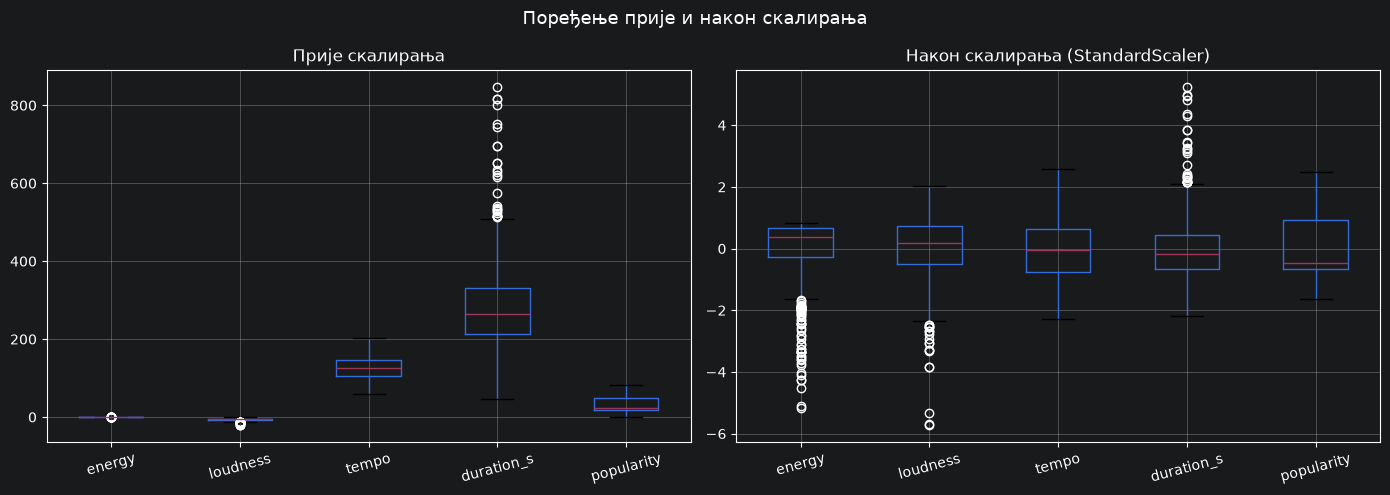

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Прије
X_train[["energy", "loudness", "tempo", "duration_s", "popularity"]].boxplot(ax=axes[0])
axes[0].set_title("Прије скалирања", fontsize=12)
axes[0].tick_params(axis="x", rotation=15)

# Након
X_train_scaled[["energy", "loudness", "tempo", "duration_s", "popularity"]].boxplot(ax=axes[1])
axes[1].set_title("Након скалирања (StandardScaler)", fontsize=12)
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Поређење прије и након скалирања", fontsize=13)
plt.tight_layout()
plt.show()

## Корак 9 – Чување припремљених података

In [9]:
import os
import joblib

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Čuvamo train/test setove
X_train_scaled.to_csv("../data/processed/X_train.csv", index=False)
X_test_scaled.to_csv("../data/processed/X_test.csv",  index=False)
y_train.to_csv("../data/processed/y_train.csv",       index=False)
y_test.to_csv("../data/processed/y_test.csv",         index=False)

# Čuvamo scaler i label encoder za kasniju upotrebu
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le,     "../models/label_encoder.pkl")

print("Сачувано:")
print("  data/processed/X_train.csv")
print("  data/processed/X_test.csv")
print("  data/processed/y_train.csv")
print("  data/processed/y_test.csv")
print("  models/scaler.pkl")
print("  models/label_encoder.pkl")
print()

print(f"  Features: {len(feature_cols)}")
print(f"  Train: {len(X_train_scaled)} примјера")
print(f"  Test:  {len(X_test_scaled)} примјера")

Сачувано:
  data/processed/X_train.csv
  data/processed/X_test.csv
  data/processed/y_train.csv
  data/processed/y_test.csv
  models/scaler.pkl
  models/label_encoder.pkl

  Features: 15
  Train: 760 примјера
  Test:  190 примјера
